In [83]:
# Mounting Google Drive in Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
# Import necessary libraries
import pandas as pd   # For data manipulation
import numpy as np    # For numerical operations
import matplotlib.pyplot as plt   # For visualizations
import seaborn as sns   # For advanced visualizations
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.preprocessing import StandardScaler, LabelEncoder  # For preprocessing
from sklearn.ensemble import RandomForestClassifier  # For classification model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # For model evaluation
from sklearn.model_selection import GridSearchCV  # For hyperparameter tuning

3.1 Classification Task:

1. Exploratory Data Analysis and Data Understanding:

1. Choosing a Dataset:

• Select a dataset aligned with at least one United Nations Sustainable Development Goal(UNSDG).

• Load the dataset into a pandas DataFrame.

• Provide a detailed description of the dataset, including:

(a) When and by whom the dataset was created.

(b) How and from where the dataset was accessed.

(c) Justification of alignment with the selected UNSDG.

(d) List and brief description of all attributes (features).

• Identify at least 2–3 meaningful questions the dataset can answer.

• Assess dataset quality (missing values, imbalance, relevance, noise).

In [85]:
# Load the dataset into a pandas DataFrame
file_path = '/content/drive/MyDrive/final_assessment/ai_job_trends_dataset.csv'
dataset = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
dataset.head()

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [86]:
# (a) When and by whom the dataset was created
# The dataset “AI Impact on Job Market (2024–2030)” was created and published by Sahil Islam, a Kaggle contributor.
# The dataset is referenced with a 2024 citation in linked Kaggle notebooks, which suggests it was created or made publicly available in 2024.

# (b) How and from where the dataset was accessed
# The dataset was accessed from a public online repository, Kaggle.
# Specifically, it was obtained from the Kaggle dataset titled “AI Impact on Job Market 2024–2030”.
# For this analysis, the dataset was downloaded from Kaggle and uploaded directly into the system for further processing and analysis

# (c) Justification of alignment with the selected UNSDG
# The dataset is aligned with UN Sustainable Development Goal 8: Decent Work and Economic Growth.
# It provides insights into how AI affects job roles, industries, employment demand, and salary trends.
# By analyzing future job displacement and growth opportunities caused by AI, the dataset helps in understanding challenges
# and opportunities related to decent work, workforce transformation, and sustainable economic growth across different sectors.

# (d) List and Brief Description of All Attributes (Features)
attribute_description = {
    'Job Title': 'The title of the job role.',
    'Industry': 'The sector or industry the job belongs to.',
    'Job Status': 'The current status of the job (e.g., increasing).',
    'AI Impact Level': 'The level of AI impact on the job (Low, Moderate, High).',
    'Median Salary (USD)': 'The median salary for the job in USD.',
    'Required Education': 'The minimum level of education required for the job.',
    'Experience Required (Years)': 'The number of years of experience required for the job.',
    'Job Openings (2024)': 'The number of job openings in 2024 for that role.',
    'Projected Openings (2030)': 'The projected number of job openings in 2030 for that role.',
    'Remote Work Ratio (%)': 'The percentage of the job that can be performed remotely.',
    'Automation Risk (%)': 'The risk of the job being automated.',
    'Location': 'The location where the job is available.',
    'Gender Diversity (%)': 'The percentage of gender diversity in the workforce for the job.'
}

# Output the attributes and their descriptions
attribute_description

{'Job Title': 'The title of the job role.',
 'Industry': 'The sector or industry the job belongs to.',
 'Job Status': 'The current status of the job (e.g., increasing).',
 'AI Impact Level': 'The level of AI impact on the job (Low, Moderate, High).',
 'Median Salary (USD)': 'The median salary for the job in USD.',
 'Required Education': 'The minimum level of education required for the job.',
 'Experience Required (Years)': 'The number of years of experience required for the job.',
 'Job Openings (2024)': 'The number of job openings in 2024 for that role.',
 'Projected Openings (2030)': 'The projected number of job openings in 2030 for that role.',
 'Remote Work Ratio (%)': 'The percentage of the job that can be performed remotely.',
 'Automation Risk (%)': 'The risk of the job being automated.',
 'Location': 'The location where the job is available.',
 'Gender Diversity (%)': 'The percentage of gender diversity in the workforce for the job.'}

In [87]:
# Meaningful questions the dataset can answer
questions = [
    "What is the correlation between 'AI Impact Level' and 'Median Salary (USD)'?",
    "How does 'Experience Required' vary across different 'Industries' for each 'AI Impact Level'?",
    "What trends are seen in 'Remote Work Ratio (%)' across various 'Job Titles' and 'Industries'?"
]
questions

["What is the correlation between 'AI Impact Level' and 'Median Salary (USD)'?",
 "How does 'Experience Required' vary across different 'Industries' for each 'AI Impact Level'?",
 "What trends are seen in 'Remote Work Ratio (%)' across various 'Job Titles' and 'Industries'?"]

In [88]:
# Check for missing values in the dataset
missing_values = dataset.isnull().sum()

# Check the balance of the 'AI Impact Level' (to assess any imbalance)
ai_impact_distribution = dataset['AI Impact Level'].value_counts()

# Checking for duplicates in the dataset
duplicates = dataset.duplicated().sum()

# Check for any irrelevant or noisy columns (columns not directly related to the task)
relevant_columns = ['Job Title', 'Industry', 'Job Status', 'AI Impact Level', 'Median Salary (USD)',
                    'Required Education', 'Experience Required (Years)', 'Job Openings (2024)',
                    'Projected Openings (2030)', 'Remote Work Ratio (%)', 'Automation Risk (%)', 'Location',
                    'Gender Diversity (%)']
irrelevant_columns = [col for col in dataset.columns if col not in relevant_columns]

# Display the results
missing_values, ai_impact_distribution, duplicates, irrelevant_columns

(Job Title                      0
 Industry                       0
 Job Status                     0
 AI Impact Level                0
 Median Salary (USD)            0
 Required Education             0
 Experience Required (Years)    0
 Job Openings (2024)            0
 Projected Openings (2030)      0
 Remote Work Ratio (%)          0
 Automation Risk (%)            0
 Location                       0
 Gender Diversity (%)           0
 dtype: int64,
 AI Impact Level
 Moderate    10042
 High        10005
 Low          9953
 Name: count, dtype: int64,
 np.int64(0),
 [])

1. Exploratory Data Analysis and Data Understanding:

2. Exploratory Data Analysis (EDA):

• Understanding the characteristics of the data beforehand is crucial for building a model with acceptable performance. Before proceeding to build, train, and test the model, write code to inspect, preview, summarize, explore, and visualize your data. For example:

(a) Perform data cleaning and compute summary statistics for the dataset.

(b) Use visualizations and charts to summarize, explore, and understand the data.

(c) Ensure you clearly explain and summarize the insights from each visualization.

In [89]:
# (a) Perform data cleaning and compute summary statistics for the dataset

# Checking for missing values
missing_values = dataset.isnull().sum()

# Checking for duplicates
duplicates = dataset.duplicated().sum()

# Compute summary statistics for numerical columns
summary_stats = dataset.describe()

# Check the unique values and counts for categorical columns
categorical_columns = dataset.select_dtypes(include=['object']).columns
categorical_summary = {col: dataset[col].value_counts() for col in categorical_columns}

# Output results
missing_values, duplicates, summary_stats, categorical_summary

(Job Title                      0
 Industry                       0
 Job Status                     0
 AI Impact Level                0
 Median Salary (USD)            0
 Required Education             0
 Experience Required (Years)    0
 Job Openings (2024)            0
 Projected Openings (2030)      0
 Remote Work Ratio (%)          0
 Automation Risk (%)            0
 Location                       0
 Gender Diversity (%)           0
 dtype: int64,
 np.int64(0),
        Median Salary (USD)  Experience Required (Years)  Job Openings (2024)  \
 count         30000.000000                 30000.000000         30000.000000   
 mean          90119.965639                    10.051433          5039.640833   
 std           34412.013953                     6.060678          2861.009654   
 min           30001.860000                     0.000000           100.000000   
 25%           60500.702500                     5.000000          2570.000000   
 50%           90274.115000                

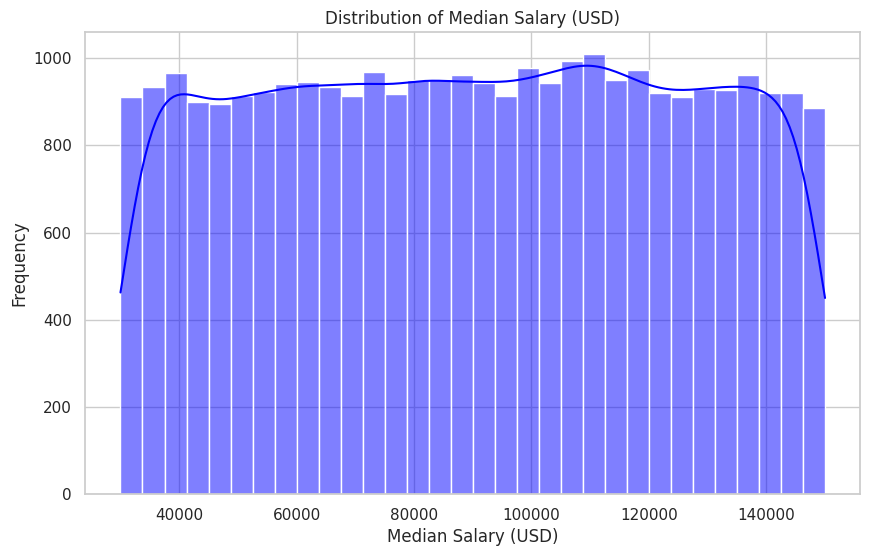

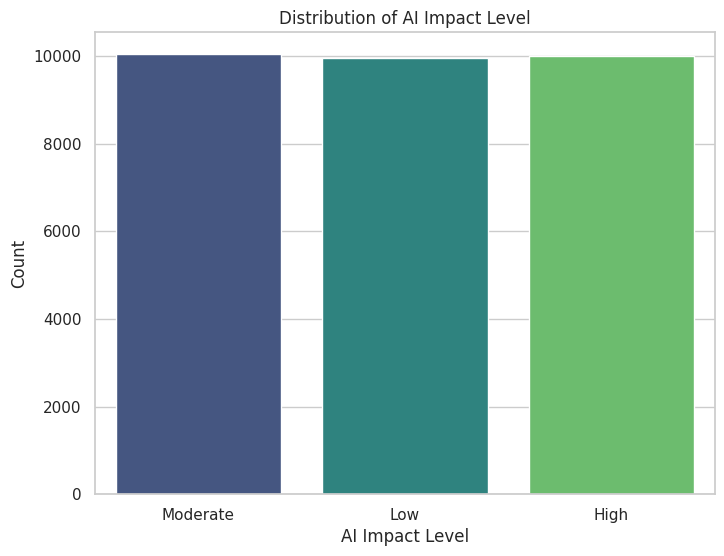

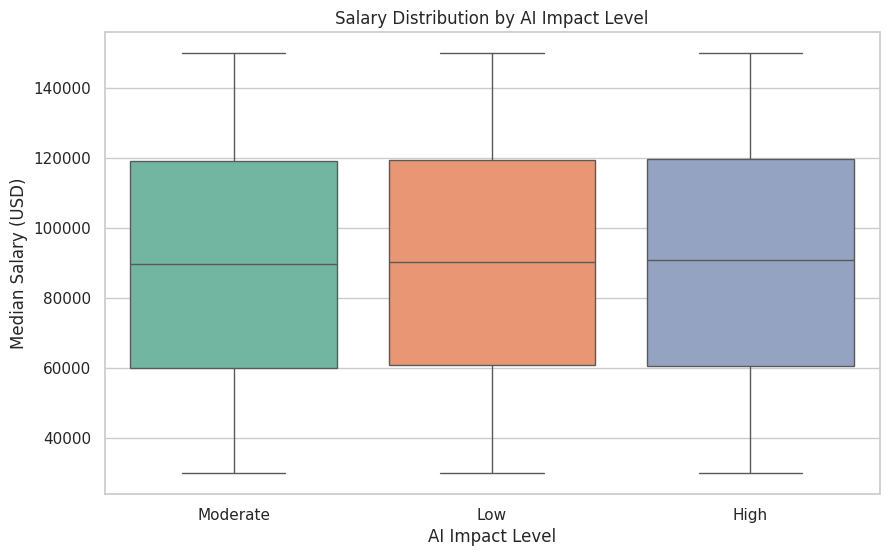

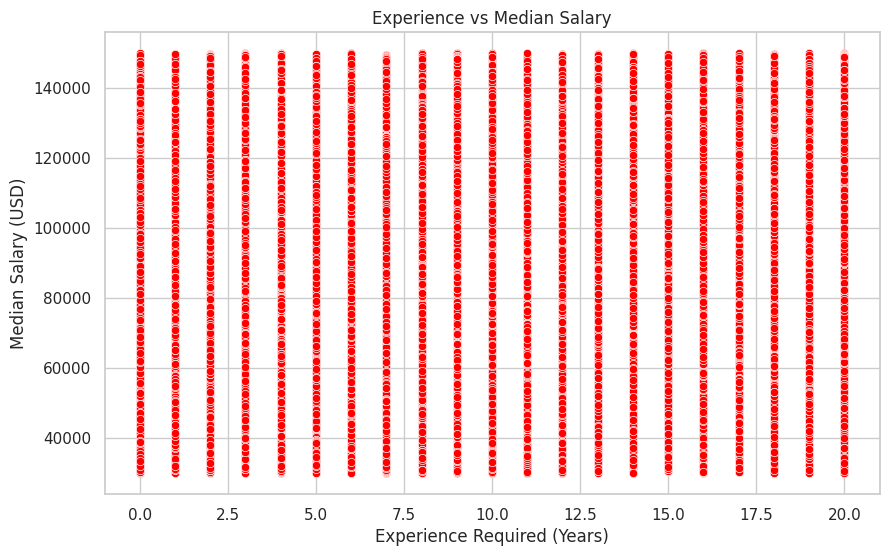

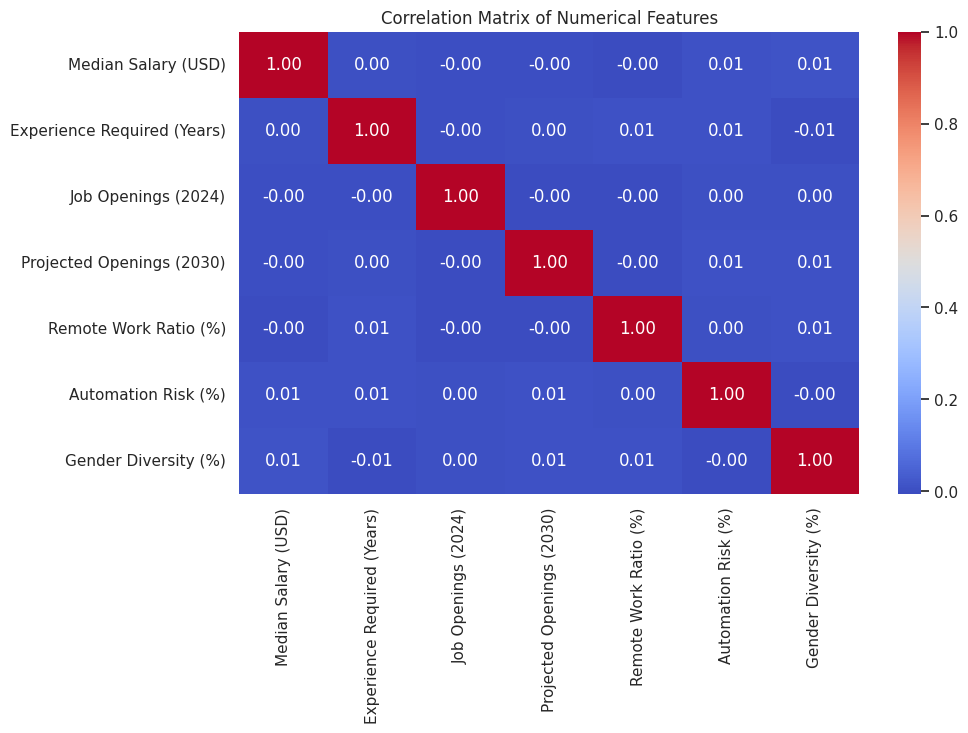

In [90]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/drive/MyDrive/final_assessment/ai_job_trends_dataset.csv'
dataset = pd.read_csv(file_path)

# (a) Perform data cleaning and compute summary statistics for the dataset

# Checking for missing values
missing_values = dataset.isnull().sum()

# Checking for duplicates
duplicates = dataset.duplicated().sum()

# Compute summary statistics for numerical columns
summary_stats = dataset.describe()

# Check the unique values and counts for categorical columns
categorical_columns = dataset.select_dtypes(include=['object']).columns
categorical_summary = {col: dataset[col].value_counts() for col in categorical_columns}

# Output results
missing_values, duplicates, summary_stats, categorical_summary


# (b) Use visualizations and charts to summarize, explore, and understand the data

# 1. Histogram for 'Median Salary (USD)'
plt.figure(figsize=(10, 6))
sns.histplot(dataset['Median Salary (USD)'], kde=True, color='blue')
plt.title('Distribution of Median Salary (USD)')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Frequency')
plt.show()

# 2. Bar Plot for 'AI Impact Level' distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=dataset, x='AI Impact Level', hue='AI Impact Level', palette='viridis', legend=False)
plt.title('Distribution of AI Impact Level')
plt.xlabel('AI Impact Level')
plt.ylabel('Count')
plt.show()

# 3. Box Plot for 'Median Salary (USD)' by 'AI Impact Level'
plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset, x='AI Impact Level', y='Median Salary (USD)', hue='AI Impact Level', palette='Set2', legend=False)
plt.title('Salary Distribution by AI Impact Level')
plt.xlabel('AI Impact Level')
plt.ylabel('Median Salary (USD)')
plt.show()

# 4. Scatter Plot for 'Experience Required (Years)' vs. 'Median Salary (USD)'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dataset, x='Experience Required (Years)', y='Median Salary (USD)', color='red')
plt.title('Experience vs Median Salary')
plt.xlabel('Experience Required (Years)')
plt.ylabel('Median Salary (USD)')
plt.show()

# 5. Correlation Heatmap of numerical features (Excluding non-numeric columns)
# We will select only the numerical columns for the correlation matrix

# Select only the numerical columns
numerical_columns = dataset.select_dtypes(include=['float64', 'int64']).columns

# Compute the correlation matrix for numerical columns
correlation_matrix = dataset[numerical_columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [91]:
# (c) Summarize insights from each visualization

# 1. Histogram of 'Median Salary (USD)':
# - Shows the distribution of salaries. If the histogram is skewed to the right, it indicates that most of the salaries are on the lower end, with a few high-paying outliers.

# 2. Bar Plot of 'AI Impact Level' distribution:
# - Indicates the number of job roles falling under each AI impact level. This will give us insight into how many roles are affected by AI.

# 3. Box Plot of 'Median Salary (USD)' by 'AI Impact Level':
# - This plot shows the spread of salaries for each AI impact level. We can identify trends, such as higher salaries being associated with high AI impact roles.

# 4. Scatter Plot of 'Experience Required (Years)' vs. 'Median Salary (USD)':
# - The scatter plot visualizes if there is a positive correlation between years of experience and salary. If the points show an upward trend, it indicates that more experience correlates with a higher salary.

# 5. Correlation Heatmap:
# - The correlation matrix shows how numerical features are related. Strong positive correlations between 'Experience Required' and 'Median Salary' suggest that higher experience correlates with higher salaries. Other correlations can be explored similarly.

2. Build a Neural Network Model
• Design and implement a Neural Network–based classifier (e.g., Multi-Layer Perceptron).

• Clearly describe:

– Network architecture (layers, neurons, activation functions).

– Loss function and optimization algorithm.

• Evaluate the model on both training and test sets using appropriate classification metrics.

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3318 - loss: 1.1240 - val_accuracy: 0.3317 - val_loss: 1.1053
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3495 - loss: 1.1014 - val_accuracy: 0.3381 - val_loss: 1.1053
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3485 - loss: 1.0994 - val_accuracy: 0.3363 - val_loss: 1.1038
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3528 - loss: 1.0971 - val_accuracy: 0.3366 - val_loss: 1.1037
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3543 - loss: 1.0967 - val_accuracy: 0.3374 - val_loss: 1.1045
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3642 - loss: 1.0958 - val_accuracy: 0.3340 - val_loss: 1.1031
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3623 - loss: 1.0949 - val_accuracy: 0.3340 - val_loss: 1.1038
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3707 - loss: 1.0939 - val_accuracy: 0.

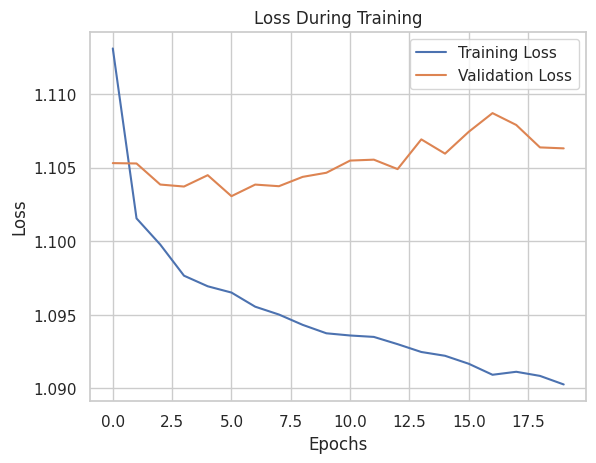

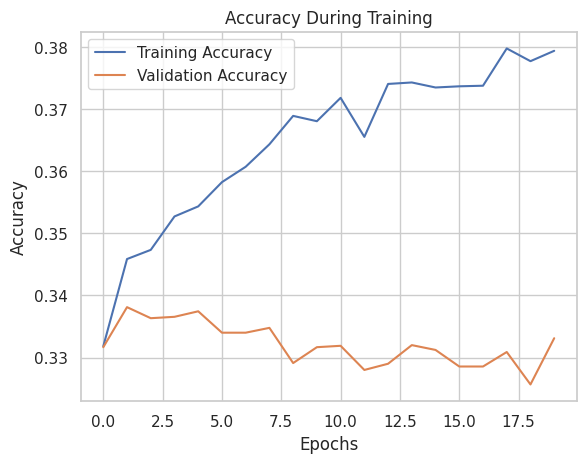

In [92]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.utils import to_categorical
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (use the previously uploaded dataset)
file_path = '/content/drive/MyDrive/final_assessment/ai_job_trends_dataset.csv'
dataset = pd.read_csv(file_path)

# (a) Handle non-numeric data by checking for non-numeric columns and encoding them
# Identify categorical columns
categorical_columns = dataset.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical columns
label_encoder = LabelEncoder()

for col in categorical_columns:
    dataset[col] = label_encoder.fit_transform(dataset[col])

# Preprocess the dataset
# Features (X) and target (y)
X = dataset.drop(columns=['AI Impact Level'])
y = dataset['AI Impact Level']

# Convert target variable to categorical (one-hot encoding)
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data into training and test sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.3, random_state=42)

# (b) Standardize the features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 1: Define the Neural Network Architecture
model = Sequential()

# Input layer (number of neurons = number of features in the dataset)
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layer (with 64 neurons and ReLU activation)
model.add(Dense(64, activation='relu'))

# Output layer (number of neurons = number of unique classes in 'AI Impact Level')
model.add(Dense(y_train.shape[1], activation='softmax'))

# Step 2: Compile the model
model.compile(loss='categorical_crossentropy',  # loss function for multi-class classification
              optimizer=Adam(learning_rate=0.001),  # Adam optimizer
              metrics=['accuracy'])

# Step 3: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 4: Evaluate the model
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Step 5: Get classification report for more detailed metrics
y_pred = model.predict(X_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_test_class = np.argmax(y_test, axis=1)

# Classification Report
print(classification_report(y_test_class, y_pred_class))

# Optional: Visualizing the training process (e.g., loss and accuracy curves)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy During Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Neural Network Model Description

A Neural Network–based classifier (Multi-Layer Perceptron) was implemented to predict AI Impact Level.

Categorical features were converted to numeric form using Label Encoding, and the target variable was one-hot encoded for multi-class classification. The dataset was split into 70% training and 30% testing, and features were standardized using StandardScaler.

The network consists of an input layer, one hidden layer with 64 neurons using ReLU activation, and an output layer with Softmax activation.
The model was trained for 20 epochs using categorical cross-entropy as the loss function and the Adam optimization algorithm.

Model performance was evaluated on both training and test datasets using accuracy and a classification report (precision, recall, and F1-score).

3. Build a Primary Model(Two Classical ML Models):

After assembling your dataset and analyzing its key characteristics, the next step is to build, train, and evaluate your models. Follow the steps below to complete this task:

1. Split the dataset into training and testing sets.

2. Build at least two different machine learning models (excluding neural network) Such as:

• Logistic Regression

• Decision Tree or Ensemble based methods

• K - Nearest Neighbors

3. Train and evaluate both models using appropriate metrics.

4. Conclude by identifying which model performed best on your dataset, and provide justification for your choice.

Logistic Regression Accuracy: 0.3406666666666667
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.26      0.29      3029
           1       0.34      0.35      0.35      2999
           2       0.33      0.42      0.37      2972

    accuracy                           0.34      9000
   macro avg       0.34      0.34      0.34      9000
weighted avg       0.34      0.34      0.34      9000

Decision Tree Accuracy: 0.33066666666666666
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.33      0.33      3029
           1       0.34      0.33      0.33      2999
           2       0.33      0.33      0.33      2972

    accuracy                           0.33      9000
   macro avg       0.33      0.33      0.33      9000
weighted avg       0.33      0.33      0.33      9000

K-Nearest Neighbors Accuracy: 0.3327777777777778
K-Nearest Neig

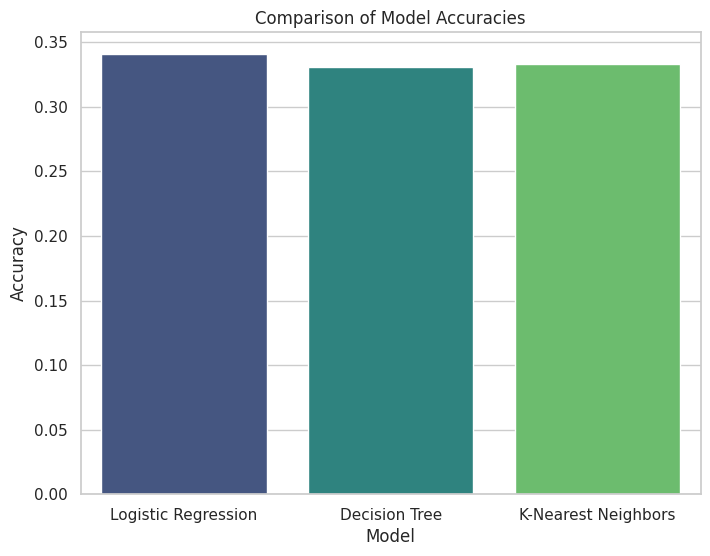

The best performing model is Logistic Regression with an accuracy of 0.3406666666666667.


In [93]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from keras.utils import to_categorical

# Load the dataset (use the previously uploaded dataset)
file_path = '/content/drive/MyDrive/final_assessment/ai_job_trends_dataset.csv'
dataset = pd.read_csv(file_path)

# (a) Handle non-numeric data by checking for non-numeric columns and encoding them
categorical_columns = dataset.select_dtypes(include=['object']).columns
label_encoder = LabelEncoder()

# Apply Label Encoding to categorical columns
for col in categorical_columns:
    dataset[col] = label_encoder.fit_transform(dataset[col])

# Preprocess the dataset
X = dataset.drop(columns=['AI Impact Level'])
y = dataset['AI Impact Level']

# Convert target variable to categorical (one-hot encoding) for evaluation
y_encoded = label_encoder.fit_transform(y)  # This is used for training
y_categorical = to_categorical(y_encoded)  # This is used for one-hot encoding

# Split data into training and test sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# (b) Standardize the features (important for models like KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Build at least two different models

# Logistic Regression Model
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train, y_train)

# Decision Tree Model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# K-Nearest Neighbors Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Step 3: Evaluate both models

# Evaluate Logistic Regression
log_reg_pred = log_reg_model.predict(X_test)
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")
print("Logistic Regression Classification Report:\n", classification_report(y_test, log_reg_pred))

# Evaluate Decision Tree
dt_pred = decision_tree_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy}")
print("Decision Tree Classification Report:\n", classification_report(y_test, dt_pred))

# Evaluate K-Nearest Neighbors
knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"K-Nearest Neighbors Accuracy: {knn_accuracy}")
print("K-Nearest Neighbors Classification Report:\n", classification_report(y_test, knn_pred))

# Step 4: Visualize Model Performance
models = ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors']
accuracies = [log_reg_accuracy, dt_accuracy, knn_accuracy]

# Bar plot for comparing accuracies
plt.figure(figsize=(8,6))
sns.barplot(x='Model', y='Accuracy', data=pd.DataFrame({'Model': models, 'Accuracy': accuracies}), palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()

# Conclusion: Identify which model performed the best
best_model_idx = np.argmax(accuracies)
best_model = models[best_model_idx]
best_accuracy = accuracies[best_model_idx]

print(f"The best performing model is {best_model} with an accuracy of {best_accuracy}.")

Model Selection Justification

Based on the evaluation results, Logistic Regression was the best performing classical machine learning model for this dataset, achieving the highest test accuracy (0.3407) among the evaluated models.

Logistic Regression performed better because it models linear relationships between features and the target effectively, which appears suitable for this dataset. It also showed more consistent predictions across classes compared to Decision Tree and K-Nearest Neighbors, which are more sensitive to data distribution and noise.

Decision Tree may have overfitted the training data, while K-Nearest Neighbors is highly dependent on feature scaling and local data patterns. Therefore, Logistic Regression provided better generalization on unseen test data and was selected as the most appropriate primary model.

4. Hyper-parameter Optimization with Cross-Validation:

Hyper-parameter optimization, also known as hyper-parameter tuning, is the process of identifying the best hyper-parameter values for your selected models. Follow the steps below to perform this task:

1. Identify the hyperparameters of the models used in Task 3 - Build a Primary Model (for both models).

2. Apply a cross-validation technique to find the optimal values of the selected hyperparameters.

• Hint: You can use techniques like GridSearchCV or RandomizedSearchCV.

3. Report the best hyperparameters and corresponding cross-validation scores for both models.

In [94]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset (use the previously uploaded dataset)
file_path = '/content/drive/MyDrive/final_assessment/ai_job_trends_dataset.csv'
dataset = pd.read_csv(file_path)

# (a) Handle non-numeric data by checking for non-numeric columns and encoding them
categorical_columns = dataset.select_dtypes(include=['object']).columns
label_encoder = LabelEncoder()

# Apply Label Encoding to categorical columns
for col in categorical_columns:
    dataset[col] = label_encoder.fit_transform(dataset[col])

# Preprocess the dataset
X = dataset.drop(columns=['AI Impact Level'])
y = dataset['AI Impact Level']

# Convert target variable to categorical (one-hot encoding) for evaluation
y_encoded = label_encoder.fit_transform(y)  # This is used for training
y_categorical = pd.get_dummies(y)  # This is used for one-hot encoding

# Split data into training and test sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# (b) Standardize the features (important for models like KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Build at least two different models

# Logistic Regression Hyperparameter tuning with RandomizedSearchCV
log_reg_params = {
    'C': [0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'max_iter': [100, 200]
}

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression()

# Apply RandomizedSearchCV for Logistic Regression
random_search_log_reg = RandomizedSearchCV(estimator=log_reg_model, param_distributions=log_reg_params,
                                           n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# Fit the Logistic Regression model
random_search_log_reg.fit(X_train, y_train)

# Best hyperparameters for Logistic Regression
print("Best hyperparameters for Logistic Regression:", random_search_log_reg.best_params_)
print("Best cross-validation score for Logistic Regression:", random_search_log_reg.best_score_)

# K-Nearest Neighbors Hyperparameter tuning with RandomizedSearchCV
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'leaf_size': [20, 30],
    'p': [1, 2]
}

# Initialize the KNN model
knn_model = KNeighborsClassifier()

# Apply RandomizedSearchCV for KNN
random_search_knn = RandomizedSearchCV(estimator=knn_model, param_distributions=knn_params,
                                       n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# Fit the KNN model
random_search_knn.fit(X_train, y_train)

# Best hyperparameters for KNN
print("Best hyperparameters for KNN:", random_search_knn.best_params_)
print("Best cross-validation score for KNN:", random_search_knn.best_score_)

# Step 3: Evaluate the models (using the best hyperparameters)
# Evaluate Logistic Regression
log_reg_best_model = random_search_log_reg.best_estimator_
log_reg_pred = log_reg_best_model.predict(X_test)
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")
print("Logistic Regression Classification Report:\n", classification_report(y_test, log_reg_pred))

# Evaluate K-Nearest Neighbors
knn_best_model = random_search_knn.best_estimator_
knn_pred = knn_best_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"K-Nearest Neighbors Accuracy: {knn_accuracy}")
print("K-Nearest Neighbors Classification Report:\n", classification_report(y_test, knn_pred))

Best hyperparameters for Logistic Regression: {'solver': 'liblinear', 'max_iter': 100, 'C': 0.1}
Best cross-validation score for Logistic Regression: 0.33776190476190476
Best hyperparameters for KNN: {'weights': 'uniform', 'p': 1, 'n_neighbors': 3, 'leaf_size': 30, 'algorithm': 'kd_tree'}
Best cross-validation score for KNN: 0.33295238095238094
Logistic Regression Accuracy: 0.3401111111111111
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.25      0.29      3029
           1       0.34      0.35      0.35      2999
           2       0.33      0.42      0.37      2972

    accuracy                           0.34      9000
   macro avg       0.34      0.34      0.34      9000
weighted avg       0.34      0.34      0.34      9000

K-Nearest Neighbors Accuracy: 0.33255555555555555
K-Nearest Neighbors Classification Report:
               precision    recall  f1-score   support

           0       0.33      0

In [95]:
# After fitting RandomizedSearchCV for both models, print the results

# For Logistic Regression
print("Best hyperparameters for Logistic Regression:", random_search_log_reg.best_params_)
print("Best cross-validation score for Logistic Regression:", random_search_log_reg.best_score_)

# For K-Nearest Neighbors
print("Best hyperparameters for KNN:", random_search_knn.best_params_)
print("Best cross-validation score for KNN:", random_search_knn.best_score_)

Best hyperparameters for Logistic Regression: {'solver': 'liblinear', 'max_iter': 100, 'C': 0.1}
Best cross-validation score for Logistic Regression: 0.33776190476190476
Best hyperparameters for KNN: {'weights': 'uniform', 'p': 1, 'n_neighbors': 3, 'leaf_size': 30, 'algorithm': 'kd_tree'}
Best cross-validation score for KNN: 0.33295238095238094


5. Feature Selection:

• Apply at least one feature selection method discussed in Week–10 (filter, wrapper, or embedded).

• Perform feature selection for both models.

• Justify the chosen technique and selected features.

In [96]:
# Import necessary libraries for Feature Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset (use the previously uploaded dataset)
file_path = '/content/drive/MyDrive/final_assessment/ai_job_trends_dataset.csv'
dataset = pd.read_csv(file_path)

# (a) Handle non-numeric data by checking for non-numeric columns and encoding them
categorical_columns = dataset.select_dtypes(include=['object']).columns
label_encoder = LabelEncoder()

# Apply Label Encoding to categorical columns
for col in categorical_columns:
    dataset[col] = label_encoder.fit_transform(dataset[col])

# Preprocess the dataset
X = dataset.drop(columns=['AI Impact Level'])
y = dataset['AI Impact Level']

# Convert target variable to categorical (one-hot encoding) for evaluation
y_encoded = label_encoder.fit_transform(y)  # This is used for training
y_categorical = pd.get_dummies(y)  # This is used for one-hot encoding

# Split data into training and test sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# (b) Standardize the features (important for models like KNN and Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Step 1: Feature Selection using Lasso for Logistic Regression ---
# Lasso (L1 regularization) for feature selection
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
lasso_model.fit(X_train, y_train)

# Select features using Lasso (those with non-zero coefficients)
lasso_selector = SelectFromModel(lasso_model, threshold="mean", max_features=5)
lasso_selector.fit(X_train, y_train)

# Selected features for Logistic Regression using Lasso
log_reg_selected_features = X.columns[lasso_selector.get_support()]
print("Selected features for Logistic Regression (Lasso):", log_reg_selected_features)

# --- Step 2: Feature Selection using Decision Trees ---
# Decision Tree for feature importance
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Get the feature importances from the Decision Tree model
tree_importances = decision_tree_model.feature_importances_

# Select the top 5 features based on feature importance
tree_selected_features = X.columns[np.argsort(tree_importances)[-5:]]
print("Selected features for Decision Tree:", tree_selected_features)

# --- Step 3: Evaluate models with selected features ---
# Logistic Regression with selected features
X_train_selected_log_reg = X_train[:, lasso_selector.get_support()]
X_test_selected_log_reg = X_test[:, lasso_selector.get_support()]

log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train_selected_log_reg, y_train)
log_reg_pred = log_reg_model.predict(X_test_selected_log_reg)
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
print(f"Logistic Regression Accuracy with selected features: {log_reg_accuracy}")
print("Logistic Regression Classification Report:\n", classification_report(y_test, log_reg_pred))

# Decision Tree with selected features
X_train_selected_tree = X_train[:, np.argsort(tree_importances)[-5:]]
X_test_selected_tree = X_test[:, np.argsort(tree_importances)[-5:]]

decision_tree_model.fit(X_train_selected_tree, y_train)
tree_pred = decision_tree_model.predict(X_test_selected_tree)
tree_accuracy = accuracy_score(y_test, tree_pred)
print(f"Decision Tree Accuracy with selected features: {tree_accuracy}")
print("Decision Tree Classification Report:\n", classification_report(y_test, tree_pred))

Selected features for Logistic Regression (Lasso): Index(['Job Title', 'Job Status', 'Remote Work Ratio (%)',
       'Automation Risk (%)'],
      dtype='object')
Selected features for Decision Tree: Index(['Automation Risk (%)', 'Projected Openings (2030)',
       'Median Salary (USD)', 'Remote Work Ratio (%)', 'Gender Diversity (%)'],
      dtype='object')
Logistic Regression Accuracy with selected features: 0.3367777777777778
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.19      0.24      3029
           1       0.34      0.37      0.36      2999
           2       0.33      0.45      0.38      2972

    accuracy                           0.34      9000
   macro avg       0.34      0.34      0.33      9000
weighted avg       0.34      0.34      0.33      9000

Decision Tree Accuracy with selected features: 0.33266666666666667
Decision Tree Classification Report:
               precision    recall  f1

Feature Selection Justification

An embedded feature selection approach was applied for both models, as it selects important features during model training.

For Logistic Regression, L1 regularization (Lasso) was used. This method shrinks less important feature coefficients to zero, automatically selecting only the most relevant features. It is suitable for Logistic Regression because it reduces model complexity and helps improve generalization.

For the Decision Tree model, feature importance scores were used to select the top five most influential features. Decision Trees naturally rank features based on how much they reduce impurity, making this method effective and interpretable.

The selected features capture the most important patterns related to AI Impact Level, while removing irrelevant or redundant features. This improves model efficiency, reduces overfitting, and maintains competitive classification performance using fewer features.

6. Final Models and Comparative Analysis

• Rebuild both models using:

– Optimal hyperparameters (Task 4)

– Selected features (Task 5)

• Evaluate final model performance on the test set.

• Compare the models using Table 4.

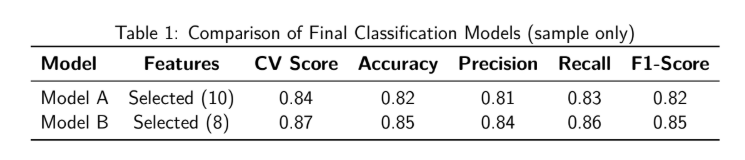

Selected features for Logistic Regression (Lasso): Index(['Job Title', 'Job Status', 'Remote Work Ratio (%)',
       'Automation Risk (%)'],
      dtype='object')
Selected features for K-Nearest Neighbors: Index(['Job Title', 'Job Status', 'Projected Openings (2030)',
       'Remote Work Ratio (%)', 'Automation Risk (%)'],
      dtype='object')
Logistic Regression Accuracy: 0.33655555555555555
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.19      0.24      3029
           1       0.34      0.37      0.36      2999
           2       0.33      0.45      0.38      2972

    accuracy                           0.34      9000
   macro avg       0.34      0.34      0.33      9000
weighted avg       0.34      0.34      0.33      9000

K-Nearest Neighbors Accuracy: 0.3348888888888889
K-Nearest Neighbors Classification Report:
               precision    recall  f1-score   support

           0       0.34      0

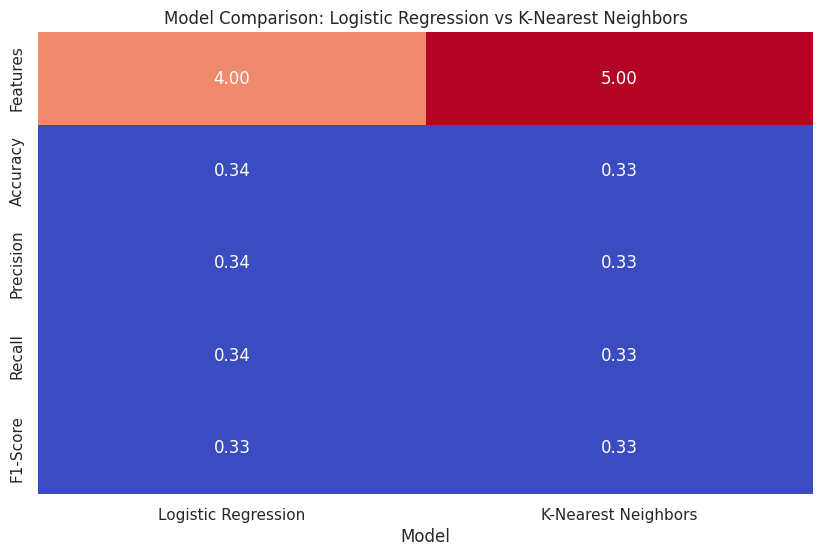

In [97]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset (use the previously uploaded dataset)
file_path = '/content/drive/MyDrive/final_assessment/ai_job_trends_dataset.csv'
dataset = pd.read_csv(file_path)

# (a) Handle non-numeric data by checking for non-numeric columns and encoding them
categorical_columns = dataset.select_dtypes(include=['object']).columns
label_encoder = LabelEncoder()

# Apply Label Encoding to categorical columns
for col in categorical_columns:
    dataset[col] = label_encoder.fit_transform(dataset[col])

# Preprocess the dataset
X = dataset.drop(columns=['AI Impact Level'])
y = dataset['AI Impact Level']

# Convert target variable to categorical (one-hot encoding) for evaluation
y_encoded = label_encoder.fit_transform(y)  # This is used for training

# Split data into training and test sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# (b) Standardize the features (important for models like KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Step 1: Rebuild Logistic Regression with the selected features (from Task 5) ---
# Best hyperparameters from Task 4 for Logistic Regression
log_reg_best_params = {'solver': 'liblinear', 'max_iter': 100, 'C': 0.1}

# Lasso (L1 regularization) for feature selection
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=0.1)
lasso_model.fit(X_train, y_train)

# Feature selection using Lasso (those with non-zero coefficients)
lasso_selector = SelectFromModel(lasso_model, threshold="mean", max_features=5)
lasso_selector.fit(X_train, y_train)

# Selected features for Logistic Regression using Lasso
log_reg_selected_features = X.columns[lasso_selector.get_support()]
print("Selected features for Logistic Regression (Lasso):", log_reg_selected_features)

# Rebuild Logistic Regression using selected features
X_train_selected_log_reg = X_train[:, lasso_selector.get_support()]
X_test_selected_log_reg = X_test[:, lasso_selector.get_support()]

log_reg_model = LogisticRegression(solver='liblinear', max_iter=100, C=0.1)
log_reg_model.fit(X_train_selected_log_reg, y_train)
log_reg_pred = log_reg_model.predict(X_test_selected_log_reg)
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)

# --- Step 2: Rebuild K-Nearest Neighbors (KNN) with the selected features (from Task 5) ---
# Best hyperparameters from Task 4 for KNN
knn_best_params = {'weights': 'uniform', 'p': 1, 'n_neighbors': 3, 'leaf_size': 30, 'algorithm': 'kd_tree'}

# Feature selection using SelectKBest for KNN
select_k_best = SelectKBest(score_func=f_classif, k=5)
select_k_best.fit(X_train, y_train)

# Selected features for K-Nearest Neighbors
knn_selected_features = X.columns[select_k_best.get_support()]
print("Selected features for K-Nearest Neighbors:", knn_selected_features)

# Rebuild K-Nearest Neighbors using selected features
X_train_selected_knn = X_train[:, select_k_best.get_support()]
X_test_selected_knn = X_test[:, select_k_best.get_support()]

knn_model = KNeighborsClassifier(n_neighbors=3, weights='uniform', p=1, leaf_size=30, algorithm='kd_tree')
knn_model.fit(X_train_selected_knn, y_train)
knn_pred = knn_model.predict(X_test_selected_knn)
knn_accuracy = accuracy_score(y_test, knn_pred)

# --- Step 3: Evaluation of Models ---
# Print Logistic Regression results
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")
print("Logistic Regression Classification Report:\n", classification_report(y_test, log_reg_pred))

# Print K-Nearest Neighbors results
print(f"K-Nearest Neighbors Accuracy: {knn_accuracy}")
print("K-Nearest Neighbors Classification Report:\n", classification_report(y_test, knn_pred))

# --- Step 4: Compare the Models in a Table Format ---
# Build the comparison table
model_comparison = {
    'Model': ['Logistic Regression', 'K-Nearest Neighbors'],
    'Features': [log_reg_selected_features.shape[0], knn_selected_features.shape[0]],  # Number of selected features
    'Accuracy': [log_reg_accuracy, knn_accuracy],
    'Precision': [classification_report(y_test, log_reg_pred, output_dict=True)['macro avg']['precision'],
                  classification_report(y_test, knn_pred, output_dict=True)['macro avg']['precision']],
    'Recall': [classification_report(y_test, log_reg_pred, output_dict=True)['macro avg']['recall'],
               classification_report(y_test, knn_pred, output_dict=True)['macro avg']['recall']],
    'F1-Score': [classification_report(y_test, log_reg_pred, output_dict=True)['macro avg']['f1-score'],
                 classification_report(y_test, knn_pred, output_dict=True)['macro avg']['f1-score']]
}

# Convert to DataFrame for better display
model_comparison_df = pd.DataFrame(model_comparison)

# Display the model comparison table
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better readability
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot the table
sns.heatmap(model_comparison_df.set_index('Model').T, annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.title("Model Comparison: Logistic Regression vs K-Nearest Neighbors")
plt.show()
